# CopThief — Results Analysis

This notebook analyses match results and the audit trail, and runs a small
**parameter sweep** to study how board size affects the effort to capture.

Run from the project root with `uv run jupyter lab`.

Sections:
1. Setup
2. Latest match: outcomes and per-subgame scores
3. Parameter sweep: grid size vs. effort to capture
4. Audit-trail sanity check

In [1]:
import json
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

from copthief.constants import Role
from copthief.llm.mock import MockProvider
from copthief.orchestrator.agent import Agent
from copthief.orchestrator.match import MatchRunner
from copthief.shared.logger import AuditLog
from copthief.strategy.heuristic import HeuristicStrategy

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = ROOT / "results"
AUDIT = ROOT / "logs" / "game_audit.log"
print("root:", ROOT)

root: C:\Users\Alon\Desktop\ex6


## 2. Latest match: outcomes and per-subgame scores

Load the most recent saved report and visualise the per-subgame scores and the
distribution of outcomes.

loaded: internal_20260621_181420.json | totals: {'cop': 120, 'thief': 30}


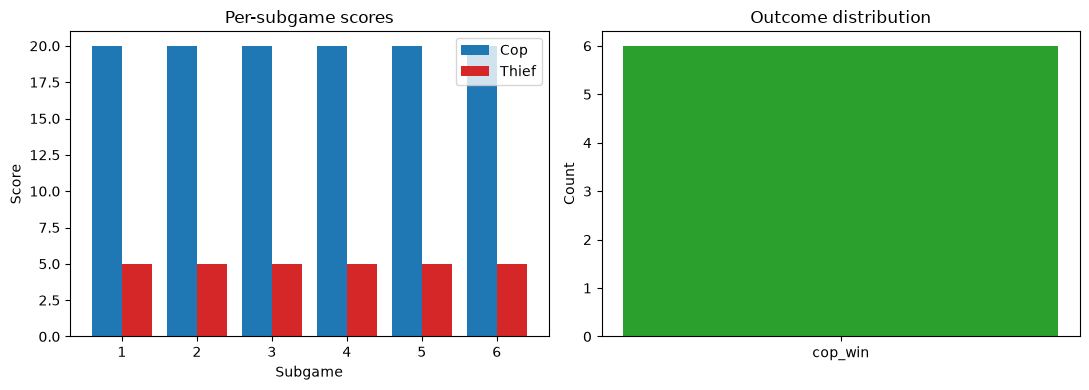

In [2]:
reports = sorted(RESULTS.glob("*.json"))
assert reports, "No reports found - run `uv run copthief selfplay` first."
report = json.loads(reports[-1].read_text(encoding="utf-8"))
sub = report["sub_games"]
print("loaded:", reports[-1].name, "| totals:", report["totals"])

idx = [s["index"] for s in sub]
cop = [s["cop_score"] for s in sub]
thief = [s["thief_score"] for s in sub]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
width = 0.4
ax1.bar([i - width / 2 for i in idx], cop, width, label="Cop", color="tab:blue")
ax1.bar([i + width / 2 for i in idx], thief, width, label="Thief", color="tab:red")
ax1.set_xlabel("Subgame")
ax1.set_ylabel("Score")
ax1.set_title("Per-subgame scores")
ax1.legend()

counts = Counter(s["outcome"] for s in sub)
ax2.bar(list(counts.keys()), list(counts.values()), color="tab:green")
ax2.set_title("Outcome distribution")
ax2.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 3. Parameter sweep: grid size vs. effort to capture

The cornering cop heuristic captures the thief reliably on a bounded grid, so the
interesting quantity is *how much effort* it takes. We run many self-play subgames
per grid size and measure both the cop capture rate and the **average number of
moves to capture** (a sensitivity analysis over the `grid_size` parameter).

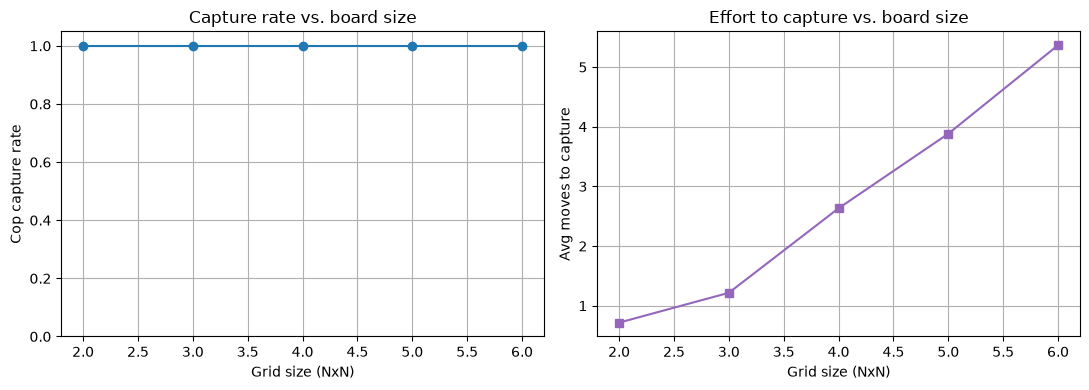

[(2, 1.0, 0.72),
 (3, 1.0, 1.22),
 (4, 1.0, 2.63),
 (5, 1.0, 3.88),
 (6, 1.0, 5.37)]

In [3]:
def sweep(size: int, trials: int = 60, seed: int = 0) -> tuple[float, float]:
    """Run trials self-play subgames; return (cop-win rate, avg moves to capture)."""
    audit = AuditLog(ROOT, {"log_dir": "logs", "game_log_file": "sweep.log"})
    scoring = {"cop_win": 20, "thief_win": 10, "cop_loss": 5, "thief_loss": 5}
    game_cfg = {"grid_size": [size, size], "max_moves": 25, "num_games": trials,
                "max_barriers": 5, "origin": 1, "diagonal_moves": True}
    cop = Agent(Role.COP, HeuristicStrategy(), MockProvider())
    thief = Agent(Role.THIEF, HeuristicStrategy(), MockProvider())
    result = MatchRunner(game_cfg, scoring, cop, thief, audit, random.Random(seed)).run_match()
    wins = [s for s in result["sub_games"] if s["outcome"] == "cop_win"]
    rate = len(wins) / trials
    avg_moves = sum(s["moves_played"] for s in wins) / len(wins) if wins else 0.0
    return rate, avg_moves

sizes = [2, 3, 4, 5, 6]
rates, moves = zip(*[sweep(s) for s in sizes], strict=True)

fig, (axa, axb) = plt.subplots(1, 2, figsize=(11, 4))
axa.plot(sizes, rates, marker="o", color="tab:blue")
axa.set_xlabel("Grid size (NxN)")
axa.set_ylabel("Cop capture rate")
axa.set_title("Capture rate vs. board size")
axa.set_ylim(0, 1.05)
axa.grid(True)
axb.plot(sizes, moves, marker="s", color="tab:purple")
axb.set_xlabel("Grid size (NxN)")
axb.set_ylabel("Avg moves to capture")
axb.set_title("Effort to capture vs. board size")
axb.grid(True)
plt.tight_layout()
plt.show()
list(zip(sizes, [round(r, 3) for r in rates], [round(m, 2) for m in moves], strict=True))

## 4. Audit-trail sanity check

The audit log is the dispute-resolution evidence trail. Here we confirm it records
every turn and that no illegal move was ever committed by the referee.

In [4]:
lines = []
if AUDIT.exists():
    lines = [json.loads(x) for x in AUDIT.read_text(encoding="utf-8").splitlines()]
events = Counter(e["event"] for e in lines)
turns = [e for e in lines if e["event"] == "turn"]
illegal = [t for t in turns if not t.get("legal", True)]
print("event counts:", dict(events))
print("total turns:", len(turns), "| illegal committed:", len(illegal))
turns[:3]

event counts: {'subgame_start': 85, 'turn': 1143, 'subgame_end': 84, 'match_complete': 14, 'turn_net': 60, 'match_complete_net': 1}
total turns: 1143 | illegal committed: 0


[{'ts': '2026-06-21T17:11:42.253163+00:00',
  'event': 'turn',
  'index': 1,
  'move': 0,
  'role': 'thief',
  'action': 'move',
  'legal': True,
  'reason': 'ok',
  'cop': [1, 5],
  'thief': [4, 1],
  'message': 'As the thief, thief moves by (1,0) and you are now at cell (4,1); this is move 1 of 25.'},
 {'ts': '2026-06-21T17:11:42.253664+00:00',
  'event': 'turn',
  'index': 1,
  'move': 1,
  'role': 'cop',
  'action': 'move',
  'legal': True,
  'reason': 'ok',
  'cop': [1, 4],
  'thief': [4, 1],
  'message': 'As the cop, cop moves by (0,-1) and you are now at cell (1,4); this is move 1 of 25.'},
 {'ts': '2026-06-21T17:11:42.254164+00:00',
  'event': 'turn',
  'index': 1,
  'move': 1,
  'role': 'thief',
  'action': 'move',
  'legal': True,
  'reason': 'ok',
  'cop': [1, 4],
  'thief': [5, 1],
  'message': 'As the thief, thief moves by (1,0) and you are now at cell (5,1); this is move 2 of 25.'}]